# Spaceship Titanic - Kaggle Competition

**Goal**: Predict which passengers were transported to an alternate dimension

This notebook includes:
- Exploratory Data Analysis
- Feature Engineering
- Model Training: XGBoost, LightGBM, Logistic Regression
- Hyperparameter Optimization with Optuna + CV
- Submission File Generation

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression

import xgboost as xgb
import lightgbm as lgb

import optuna
from optuna.samplers import TPESampler

import mlflow

import warnings
warnings.filterwarnings('ignore')

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

c:\Users\BetrisT\anaconda3\envs\model\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


In [2]:
!python --version
!pip --version


Python 3.13.11
pip 26.0.1 from C:\Users\BetrisT\anaconda3\envs\model\Lib\site-packages\pip (python 3.13)



## 2. Load Data

In [3]:
# Load training data
train_df = pd.read_csv('train.csv')

print(f"Training data shape: {train_df.shape}")
print(f"\nFirst few rows:")
train_df.head()

Training data shape: (8693, 14)

First few rows:


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
# Data info
print("Dataset Info:")
print(train_df.info())
print("\nMissing Values:")
print(train_df.isnull().sum())
print("\nTarget Distribution:")
print(train_df['Transported'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None

Missing Values:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age   

In [5]:
# Statistical summary
train_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


## 3. Exploratory Data Analysis

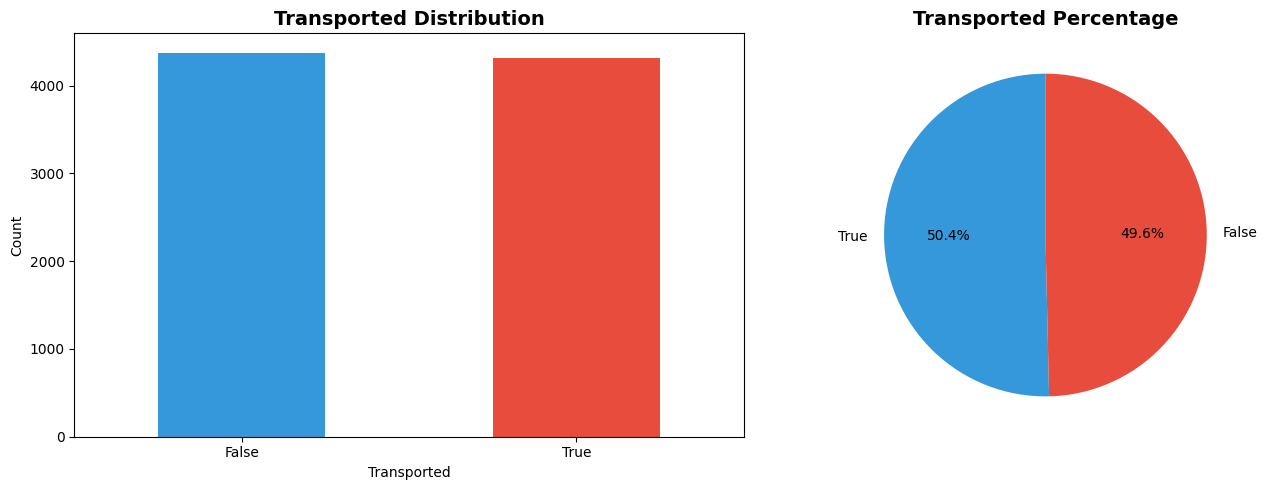

In [6]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
train_df['Transported'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Transported Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transported')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['False', 'True'], rotation=0)

# Pie chart
train_df['Transported'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                             colors=['#3498db', '#e74c3c'], startangle=90)
axes[1].set_title('Transported Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

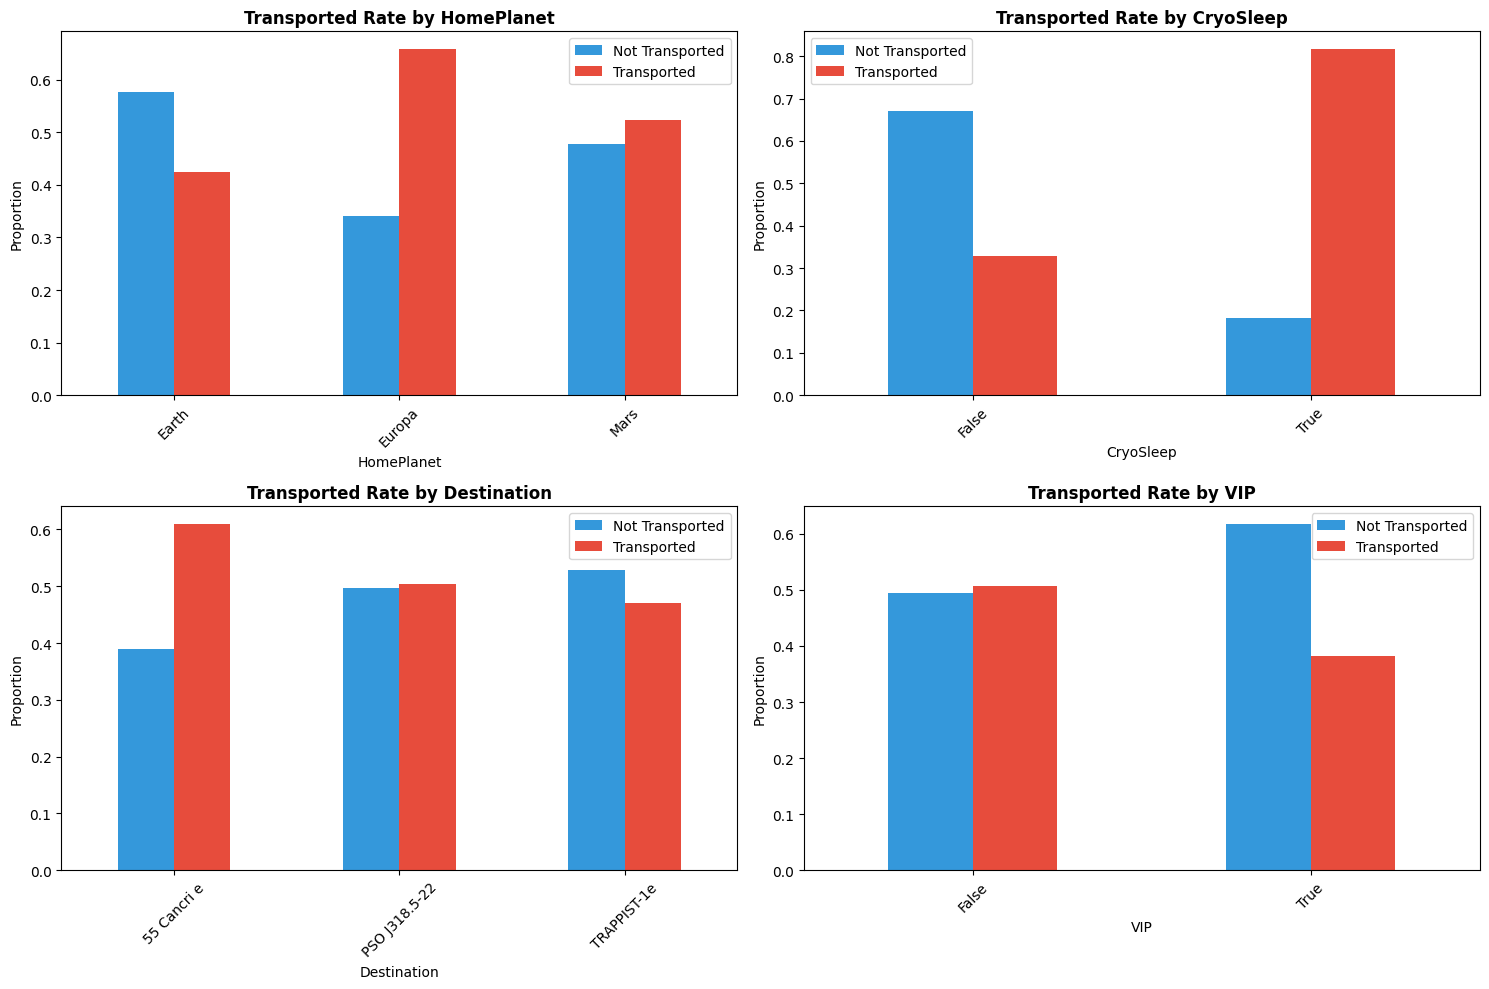

In [7]:
# Categorical features analysis
categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_features):
    pd.crosstab(train_df[col], train_df['Transported'], normalize='index').plot(
        kind='bar', ax=axes[idx], color=['#3498db', '#e74c3c']
    )
    axes[idx].set_title(f'Transported Rate by {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Proportion')
    axes[idx].legend(['Not Transported', 'Transported'])
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

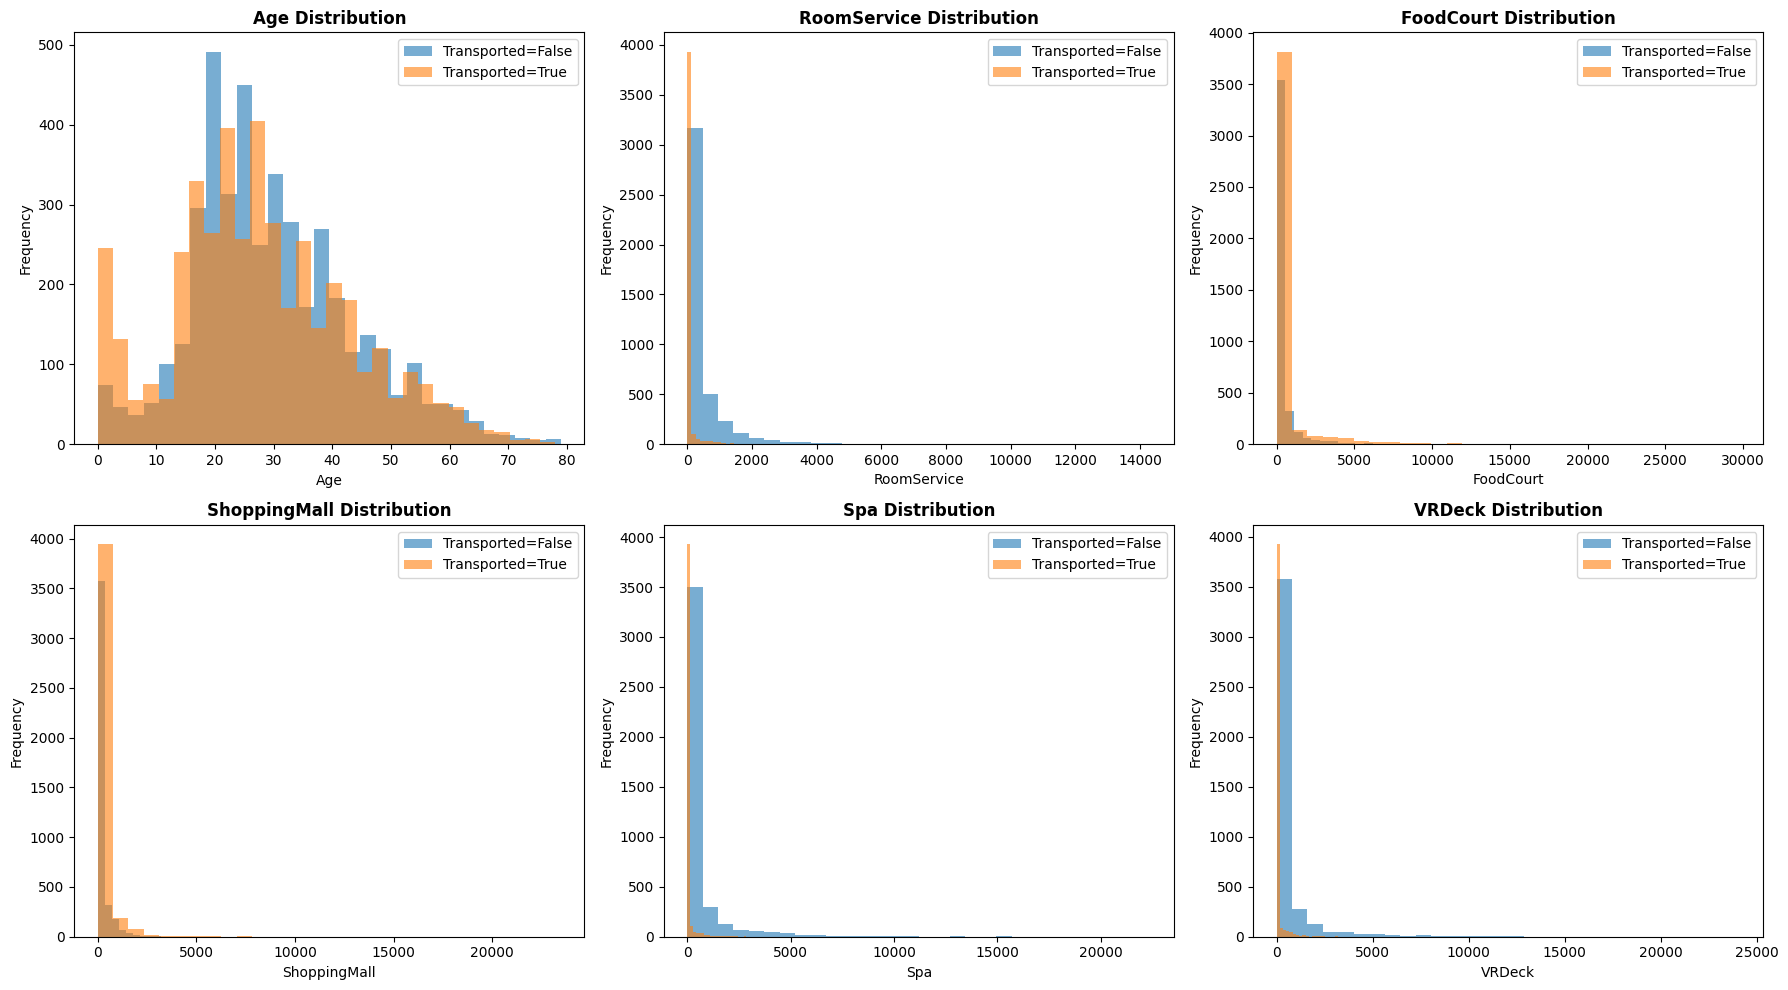

In [8]:
# Numerical features distribution
numerical_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    for transported in [False, True]:
        data = train_df[train_df['Transported'] == transported][col].dropna()
        axes[idx].hist(data, bins=30, alpha=0.6, label=f'Transported={transported}')
    
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [9]:
def feature_engineering(df):
    """Apply comprehensive feature engineering"""
    df = df.copy()
    
    # Extract features from Cabin
    df['Deck'] = df['Cabin'].apply(lambda x: x.split('/')[0] if pd.notna(x) else 'Unknown')
    df['Cabin_num'] = df['Cabin'].apply(lambda x: x.split('/')[1] if pd.notna(x) else -1).astype(float)
    df['Side'] = df['Cabin'].apply(lambda x: x.split('/')[2] if pd.notna(x) else 'Unknown')
    
    # Extract group and individual from PassengerId
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
    df['Group_size'] = df.groupby('Group')['Group'].transform('count')
    df['Solo'] = (df['Group_size'] == 1).astype(int)
    
    # Extract first and last name
    df['FirstName'] = df['Name'].apply(lambda x: x.split()[0] if pd.notna(x) else 'Unknown')
    df['LastName'] = df['Name'].apply(lambda x: x.split()[-1] if pd.notna(x) else 'Unknown')
    df['Family_size'] = df.groupby('LastName')['LastName'].transform('count')
    
    # Total spending features
    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpending'] = df[spending_cols].sum(axis=1)
    df['HasSpending'] = (df['TotalSpending'] > 0).astype(int)
    df['NoSpending'] = (df['TotalSpending'] == 0).astype(int)
    
    # Spending ratios
    for col in spending_cols:
        df[f'{col}_ratio'] = df[col] / (df['TotalSpending'] + 1)
    
    # Age groups
    df['Age_group'] = pd.cut(df['Age'], bins=[0, 12, 18, 30, 50, 100], 
                              labels=['Child', 'Teen', 'Young_Adult', 'Adult', 'Senior'])
    df['Age_group'] = df['Age_group'].astype(str)
    
    # Missing value indicators
    df['Age_missing'] = df['Age'].isna().astype(int)
    df['CryoSleep_missing'] = df['CryoSleep'].isna().astype(int)
    
    return df

# Apply feature engineering
train_df = feature_engineering(train_df)

print(f"After feature engineering: {train_df.shape}")
print(f"\nNew features created:")
print(train_df.columns.tolist())

After feature engineering: (8693, 34)

New features created:
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported', 'Deck', 'Cabin_num', 'Side', 'Group', 'Group_size', 'Solo', 'FirstName', 'LastName', 'Family_size', 'TotalSpending', 'HasSpending', 'NoSpending', 'RoomService_ratio', 'FoodCourt_ratio', 'ShoppingMall_ratio', 'Spa_ratio', 'VRDeck_ratio', 'Age_group', 'Age_missing', 'CryoSleep_missing']


## 5. Data Preprocessing

In [10]:
def preprocess_data(df, is_train=True):
    """Preprocess the data for modeling"""
    df = df.copy()
    
    # Define features to use
    categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'Age_group']
    numerical_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
                         'Cabin_num', 'Group_size', 'Solo', 'Family_size', 'TotalSpending',
                         'HasSpending', 'NoSpending', 'Age_missing', 'CryoSleep_missing'] + \
                        [col for col in df.columns if '_ratio' in col]
    
    # Fill missing values
    for col in categorical_features:
        df[col] = df[col].fillna('Unknown')
    
    for col in numerical_features:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())
    
    # Encode categorical features
    label_encoders = {}
    for col in categorical_features:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
    
    # Select features
    feature_columns = categorical_features + numerical_features
    X = df[feature_columns]
    
    if is_train:
        y = df['Transported'].astype(int)
        return X, y, feature_columns
    else:
        return X, feature_columns

# Preprocess training data
X, y, feature_columns = preprocess_data(train_df, is_train=True)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {len(feature_columns)}")
print(feature_columns)

Features shape: (8693, 27)
Target shape: (8693,)

Features used: 27
['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'Age_group', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin_num', 'Group_size', 'Solo', 'Family_size', 'TotalSpending', 'HasSpending', 'NoSpending', 'Age_missing', 'CryoSleep_missing', 'RoomService_ratio', 'FoodCourt_ratio', 'ShoppingMall_ratio', 'Spa_ratio', 'VRDeck_ratio']


In [11]:
# Split data for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"\nClass distribution in training:")
print(y_train.value_counts(normalize=True))

Training set: (6954, 27)
Validation set: (1739, 27)

Class distribution in training:
Transported
1    0.503595
0    0.496405
Name: proportion, dtype: float64


## 6. Baseline Models (No Optimization)

In [12]:
# Store results
baseline_results = {}

# XGBoost Baseline
print("Training XGBoost Baseline...")
xgb_baseline = xgb.XGBClassifier(random_state=RANDOM_STATE)
xgb_baseline.fit(X_train, y_train)
xgb_pred = xgb_baseline.predict(X_val)
xgb_acc = accuracy_score(y_val, xgb_pred)
baseline_results['XGBoost'] = xgb_acc
print(f"XGBoost Baseline Accuracy: {xgb_acc:.4f}\n")

# LightGBM Baseline
print("Training LightGBM Baseline...")
lgb_baseline = lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
lgb_baseline.fit(X_train, y_train)
lgb_pred = lgb_baseline.predict(X_val)
lgb_acc = accuracy_score(y_val, lgb_pred)
baseline_results['LightGBM'] = lgb_acc
print(f"LightGBM Baseline Accuracy: {lgb_acc:.4f}\n")

# Logistic Regression Baseline (Expected Worst Performer)
print("Training Logistic Regression Baseline...")
lr_baseline = LogisticRegression(random_state=RANDOM_STATE)
lr_baseline.fit(X_train, y_train)
lr_pred = lr_baseline.predict(X_val)
lr_acc = accuracy_score(y_val, lr_pred)
baseline_results['LogisticRegression'] = lr_acc
print(f"Logistic Regression Baseline Accuracy: {lr_acc:.4f}\n")

# Display results
baseline_df = pd.DataFrame.from_dict(baseline_results, orient='index', columns=['Accuracy'])
baseline_df = baseline_df.sort_values('Accuracy', ascending=False)
print("\n=== BASELINE RESULTS ===")
print(baseline_df)

Training XGBoost Baseline...
XGBoost Baseline Accuracy: 0.7993

Training LightGBM Baseline...
LightGBM Baseline Accuracy: 0.8108

Training Logistic Regression Baseline...
Logistic Regression Baseline Accuracy: 0.7700


=== BASELINE RESULTS ===
                    Accuracy
LightGBM            0.810811
XGBoost             0.799310
LogisticRegression  0.769983


## 7. Hyperparameter Optimization with Optuna

I'll optimize one models using Optuna with cross-validation.
**You have to optimize the other two**

In [13]:
# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### 7.1 Logistic Regression Optimization

In [14]:
def objective_lr(trial):
    """Optuna objective for Logistic Regression"""
    params = {
        'C': trial.suggest_float('C', 0.001, 100, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'saga']),
        'max_iter': trial.suggest_int('max_iter', 100, 2000),
        'random_state': RANDOM_STATE
    }
    
    # Handle incompatible penalty-solver combinations
    if params['solver'] == 'liblinear' and params['penalty'] not in ['l1', 'l2']:
        params['penalty'] = 'l2'
    
    model = LogisticRegression(**params)
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

print("Optimizing Logistic Regression...")
from optuna.samplers import TPESampler

# Set a seed for reproducibility
sampler = TPESampler(seed=RANDOM_STATE)

study_lr = optuna.create_study(direction='maximize', study_name='logistic_regression_optimization', sampler=sampler)
study_lr.optimize(objective_lr, n_trials=30, show_progress_bar=True)

print(f"\nBest Logistic Regression CV Accuracy: {study_lr.best_value:.4f}")
print(f"Best parameters: {study_lr.best_params}")

[I 2026-02-22 16:51:48,097] A new study created in memory with name: logistic_regression_optimization


Optimizing Logistic Regression...


Best trial: 0. Best value: 0.789025:   3%|▎         | 1/30 [00:06<03:04,  6.35s/it]

[I 2026-02-22 16:51:54,448] Trial 0 finished with value: 0.7890252125641299 and parameters: {'C': 0.0745934328572655, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 396}. Best is trial 0 with value: 0.7890252125641299.


Best trial: 0. Best value: 0.789025:   7%|▋         | 2/30 [00:11<02:34,  5.53s/it]

...

[I 2026-02-22 16:52:32,869] Trial 25 finished with value: 0.7838488979884078 and parameters: {'C': 0.0033259259914135268, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 888}. Best is trial 18 with value: 0.793051176191494.


Best trial: 18. Best value: 0.793051:  93%|█████████▎| 28/30 [00:47<00:01,  1.42it/s]

[I 2026-02-22 16:52:35,659] Trial 26 finished with value: 0.7814329889471285 and parameters: {'C': 0.044446525937544085, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 461}. Best is trial 18 with value: 0.793051176191494.
[I 2026-02-22 16:52:35,797] Trial 27 finished with value: 0.7925911416889063 and parameters: {'C': 0.012364752670984342, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 641}. Best is trial 18 with value: 0.793051176191494.


Best trial: 18. Best value: 0.793051: 100%|██████████| 30/30 [00:48<00:00,  1.60s/it]

[I 2026-02-22 16:52:35,964] Trial 28 finished with value: 0.7896002556923645 and parameters: {'C': 0.105366328715293, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 268}. Best is trial 18 with value: 0.793051176191494.
[I 2026-02-22 16:52:36,112] Trial 29 finished with value: 0.7905206555624008 and parameters: {'C': 0.06443935162614169, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 413}. Best is trial 18 with value: 0.793051176191494.

Best Logistic Regression CV Accuracy: 0.7931
Best parameters: {'C': 0.006579496388600943, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 485}


## 8. Train Final Models with Best Parameters

In [15]:
# Train final models on full training data
print("Training final models with optimized parameters...\n")

# Logistic Regression
print("Training Logistic Regression...")
lr_final = LogisticRegression(**study_lr.best_params, random_state=RANDOM_STATE)
lr_final.fit(X, y)

print("\nModel trained successfully!")

Training final models with optimized parameters...

Training Logistic Regression...

Model trained successfully!


## 13. Create Submission File

In [ ]:
# Load test data
test_df = pd.read_csv('test.csv')
test_passenger_ids = test_df['PassengerId'].copy()

# Preprocess
test_df = feature_engineering(test_df)
X_test, _ = preprocess_data(test_df, is_train=False)

# Predict
predictions = lr_final.predict(X_test)

# Create submission
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': predictions.astype(bool)
})

# Save
submission.to_csv('submission.csv', index=False)

## 14. Create 2 model XGBoost and LGBM Clasifier

In [17]:
def objective_xgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    model = xgb.XGBClassifier(**params)

    scores = cross_val_score(model,X,y,cv=cv,scoring="accuracy",error_score="raise")
    return scores.mean()

print("Optimizing XGBoost Classifier...")
sampler = TPESampler(seed=RANDOM_STATE)
study_xgb = optuna.create_study(direction="maximize",study_name="xgboost_optimization",sampler=sampler)
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=None)

def objective_lgbm(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "random_state": RANDOM_STATE
    }
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model,X,y,cv=cv,scoring="accuracy",error_score="raise")
    return scores.mean()

print("Optimizing LGBM Classifier...")

sampler = TPESampler(seed=RANDOM_STATE)

study_lgbm = optuna.create_study(direction="maximize",study_name="lgbm_optimization",sampler=sampler)
study_lgbm.optimize(objective_lgbm, n_trials=30, show_progress_bar=None)

print(f"\nBest LGBM Classifier CV Accuracy: {study_lgbm.best_value:.4f}")
print(f"Best parameters: {study_lgbm.best_params}")
print(f"\nBest XGBoost CV Accuracy: {study_xgb.best_value:.4f}")
print(f"Best parameters: {study_xgb.best_params}")


Optimizing XGBoost Classifier...


[I 2026-02-22 16:52:36,345] A new study created in memory with name: xgboost_optimization
[I 2026-02-22 16:53:39,591] Trial 0 finished with value: 0.800758276088198 and parameters: {'learning_rate': 0.03574712922600244, 'n_estimators': 1151, 'max_depth': 8, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746}. Best is trial 0 with value: 0.800758276088198.
[I 2026-02-22 16:53:49,841] Trial 1 finished with value: 0.8060498639814556 and parameters: {'learning_rate': 0.01699897838270077, 'n_estimators': 258, 'max_depth': 9, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184181}. Best is trial 1 with value: 0.8060498639814556.
[I 2026-02-22 16:54:34,237] Trial 2 finished with value: 0.8077755889229092 and parameters: {'learning_rate': 0.010725209743171996, 'n_estimators': 1170, 'max_depth': 9, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402}. Best is trial 2 with value: 0.8077755889229092.
[I 2026-02-22 16:54:47,291] Trial 3 fin

Optimizing LGBM Classifier...


[I 2026-02-22 17:00:29,431] Trial 0 finished with value: 0.8074301660081353 and parameters: {'learning_rate': 0.015355286838886862, 'n_estimators': 1436, 'num_leaves': 192, 'max_depth': 8, 'min_child_samples': 24}. Best is trial 0 with value: 0.8074301660081353.
[I 2026-02-22 17:00:36,179] Trial 1 finished with value: 0.8021387766337942 and parameters: {'learning_rate': 0.00797854234707418, 'n_estimators': 275, 'num_leaves': 224, 'max_depth': 9, 'min_child_samples': 74}. Best is trial 0 with value: 0.8074301660081353.
[I 2026-02-22 17:00:52,481] Trial 2 finished with value: 0.8085814433781037 and parameters: {'learning_rate': 0.005318033256270142, 'n_estimators': 1461, 'num_leaves': 216, 'max_depth': 5, 'min_child_samples': 26}. Best is trial 2 with value: 0.8085814433781037.
[I 2026-02-22 17:01:03,566] Trial 3 finished with value: 0.8096161239710931 and parameters: {'learning_rate': 0.008661333735273127, 'n_estimators': 595, 'num_leaves': 142, 'max_depth': 7, 'min_child_samples': 36}.


Best LGBM Classifier CV Accuracy: 0.8167
Best parameters: {'learning_rate': 0.007206848764305203, 'n_estimators': 844, 'num_leaves': 24, 'max_depth': 12, 'min_child_samples': 33}

Best XGBoost CV Accuracy: 0.8104
Best parameters: {'learning_rate': 0.03474283420106894, 'n_estimators': 305, 'max_depth': 7, 'subsample': 0.8436224740245504, 'colsample_bytree': 0.8143351178306898}


## 15. ML Flow experiment tracking

In [18]:
from mlflow.models import infer_signature
# Set experiment name
experiment_name = "Assignment Sesi 2"
mlflow.set_experiment(experiment_name)


2026/02/22 17:06:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/22 17:06:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/22 17:06:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/22 17:06:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/22 17:06:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/22 17:06:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/22 17:06:35 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/22 17:06:35 INFO alembic.runtime.migration: Will assume non-transactional DDL.


<Experiment: artifact_location='file:c:/BetrisN/Kuliah/Sems 4/Model Deployment/ASG Session 2/mlruns/3', creation_time=1771727854449, experiment_id='3', last_update_time=1771727854449, lifecycle_stage='active', name='Assignment Sesi 2', tags={}>

#### **Model XGBOOST Classifier**

In [19]:
import mlflow.xgboost
import mlflow.lightgbm

In [20]:
# Start MLflow run for Logistic Regression
with mlflow.start_run(run_name="XGBoost_baseline") as run:
    # Log tags
    mlflow.set_tag("model_type", "XGBoost")
    mlflow.set_tag("dataset", "spaceship")
    mlflow.set_tag("developer", "student")
    
    # Train model
    xgb_model = xgb.XGBClassifier(random_state=42)
    xgb_model.fit(X_train, y_train)
    
    # Log parameters
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("learning_rate", xgb_model.learning_rate)
    mlflow.log_param("max_depth", xgb_model.max_depth)
    mlflow.log_param("subsample", xgb_model.subsample)
    mlflow.log_param("colsample_bytree", xgb_model.colsample_bytree)
        
    # Predictions
    y_pred_xgb = xgb_model.predict(X_val)
    
    # Cross Validation
    scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy')

    # Log CV Metrics
    mlflow.log_metric("cv_mean_accuracy", scores.mean())
    mlflow.log_metric("cv_std_accuracy", scores.std())
    mlflow.log_metric("test_samples", len(X_val))
    
     # Create and save confusion matrix
    cm = confusion_matrix(y_val, y_pred_xgb)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=["False", "True"],
                yticklabels=["False", "True"])
    plt.title('XGBoost Clasifier Baseline - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('XGBoost_confusion_matrix.png')
    mlflow.log_artifact('XGBoost_confusion_matrix.png')
    plt.close()
    
    # Log model with signature
    signature = infer_signature(X_train, xgb_model.predict(X_train))
    mlflow.xgboost.log_model(xgb_model, "model", signature=signature)
    
    print(f"MLflow Run ID: {run.info.run_id}")
    print(f"Mean Accuracy: {scores.mean():.4f}")
    
print("\n=== XGBoost Classifier Results ===")
print(f"Accuracy: {scores.mean():.4f}")

2026/02/22 17:06:36 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/02/22 17:06:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instea

MLflow Run ID: 94f22a084a8745e7953467578c69e3d3
Mean Accuracy: 0.7961

=== XGBoost Classifier Results ===
Accuracy: 0.7961


#### **Model LightGBM Classifier**

In [21]:
# Start MLflow run for Logistic Regression
with mlflow.start_run(run_name="LGBM_baseline") as run:
    # Log tags
    mlflow.set_tag("model_type", "LightGBM")
    mlflow.set_tag("dataset", "spaceship")
    mlflow.set_tag("developer", "student")
    
    # Train model
    lgb_model = lgb.LGBMClassifier(random_state=42)
    lgb_model.fit(X_train, y_train)
    
    # Log parameters
    mlflow.log_param("model_type", "LightGBM")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("learning_rate", lgb_model.learning_rate)
    mlflow.log_param("n_estimators", lgb_model.n_estimators)
    mlflow.log_param("num_leaves", lgb_model.num_leaves)
    mlflow.log_param("min_child_samples", lgb_model.min_child_samples)

    # Predictions
    y_pred_lgb = lgb_model.predict(X_val)
    
    # Cross Validation
    scores = cross_val_score(lgb_model, X_train, y_train, cv=5, scoring='accuracy')

    # Log CV Metrics
    mlflow.log_metric("cv_mean_accuracy", scores.mean())
    mlflow.log_metric("cv_std_accuracy", scores.std())
    mlflow.log_metric("test_samples", len(X_val))
    
    # Create and save confusion matrix
    cm = confusion_matrix(y_val, y_pred_lgb)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=["False", "True"],
                yticklabels=["False", "True"])
    plt.title('LightBM Clasifier Baseline - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('Lgbm_confusion_matrix.png')
    mlflow.log_artifact('Lgbm_confusion_matrix.png')
    plt.close()

    # Log model with signature
    signature = infer_signature(X_train, lgb_model.predict(X_train))
    mlflow.lightgbm.log_model(lgb_model, "model", signature=signature)
    
    print(f"MLflow Run ID: {run.info.run_id}")
    print(f"Mean Accuracy: {scores.mean():.4f}")
    
print("\n=== LightBM Classifier Results ===")
print(f"Accuracy: {scores.mean():.4f}")

2026/02/22 17:07:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/22 17:07:07 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.


MLflow Run ID: 4f320357168a48b5828f1d58bfd69f9b
Mean Accuracy: 0.8014

=== LightBM Classifier Results ===
Accuracy: 0.8014


#### **Model Logistic Regression**

In [22]:
# Start MLflow run for Logistic Regression
with mlflow.start_run(run_name="LogisticRegression_baseline") as run:
    # Log tags
    mlflow.set_tag("model_type", "LogisticRegression")
    mlflow.set_tag("dataset", "spaceship")
    mlflow.set_tag("developer", "student")
    
    # Train model
    lr_model = LogisticRegression(random_state=RANDOM_STATE)
    lr_model.fit(X_train, y_train)

    # Log parameters
    mlflow.log_param("model_type", "Logistic_Regression")
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("C", lr_model.C)
    mlflow.log_param("penalty", lr_model.penalty)
    mlflow.log_param("solver", lr_model.solver)
    mlflow.log_param("max_iter", lr_model.max_iter)
        
    # Predictions
    y_pred_lr = lr_model.predict(X_val)
    
    # Cross Validation
    scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='accuracy')

    # Log CV Metrics
    mlflow.log_metric("cv_mean_accuracy", scores.mean())
    mlflow.log_metric("cv_std_accuracy", scores.std())
    mlflow.log_metric("test_samples", len(X_val))
    
    # Create and save confusion matrix
    cm = confusion_matrix(y_val, y_pred_lr)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=["False", "True"],
                yticklabels=["False", "True"])
    plt.title('Logistic Regression Baseline - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('LogistricReg_confusion_matrix.png')
    mlflow.log_artifact('LogistricReg_confusion_matrix.png')
    plt.close()

    # Log model with signature
    signature = infer_signature(X_train, lr_model.predict(X_train))
    mlflow.sklearn.log_model(lr_model, "model", signature=signature)
    
    print(f"MLflow Run ID: {run.info.run_id}")
    print(f"Mean Accuracy: {scores.mean():.4f}")
    
print("\n=== Logistic Regression Classifier Results ===")
print(f"Accuracy: {scores.mean():.4f}")

2026/02/22 17:07:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow Run ID: 45f8e66c42864996947eb5f2b3b48a62
Mean Accuracy: 0.7770

=== Logistic Regression Classifier Results ===
Accuracy: 0.7770


### **Model Optimization**

In [23]:
def objective(trial):
    """Objective function for Optuna to optimize Logistic Regression hyperparameters"""
    
    # Start a nested MLflow run for this trial
    with mlflow.start_run(run_name=f"lr_trial_{trial.number}", nested=True):

        # Suggest hyperparameters
        C = trial.suggest_float("C", 1e-4, 10, log=True)
        solver = trial.suggest_categorical("solver", ["liblinear", "lbfgs", "saga"])
        penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
        max_iter = trial.suggest_int("max_iter", 100, 1000)

        # --- Handle invalid combinations ---
        if solver in ["lbfgs"] and penalty == "l1":
            raise optuna.exceptions.TrialPruned()

        # Log parameters to MLflow
        mlflow.log_param("C", C)
        mlflow.log_param("solver", solver)
        mlflow.log_param("penalty", penalty)
        mlflow.log_param("max_iter", max_iter)
        mlflow.log_param("random_state", 42)

        # Log tags
        mlflow.set_tag("model_type", "logistic_regression")
        mlflow.set_tag("dataset", "spaceship")
        mlflow.set_tag("optimized", "true")
        mlflow.set_tag("trial_number", trial.number)

        # Create and evaluate model
        model = LogisticRegression(
            C=C,
            solver=solver,
            penalty=penalty,
            max_iter=max_iter,
            random_state=42,
        )

        # Cross-validation
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
        mean_score = scores.mean()
        std_score = scores.std()

        # Log metrics
        mlflow.log_metric("cv_accuracy_mean", mean_score)
        mlflow.log_metric("cv_accuracy_std", std_score)

        return mean_score

with mlflow.start_run(run_name="logreg_optimization") as parent_run:
    mlflow.set_tag("model_type", "logistic_regression")
    mlflow.set_tag("optimization", "optuna")
    mlflow.set_tag("dataset", "spaceship")

    print("Starting Optuna optimization for Logistic Regression...\n")

    lr_study = optuna.create_study(direction="maximize", study_name="logreg_optimization")
    lr_study.optimize(objective, n_trials=50, show_progress_bar=True)

    # Log best trial info
    mlflow.log_param("n_trials", 50)
    mlflow.log_param("best_C", lr_study.best_params["C"])
    mlflow.log_param("best_solver", lr_study.best_params["solver"])
    mlflow.log_param("best_penalty", lr_study.best_params["penalty"])
    mlflow.log_param("best_max_iter", lr_study.best_params["max_iter"])
    mlflow.log_metric("best_cv_accuracy", lr_study.best_value)

    print(f"\nParent MLflow Run ID: {parent_run.info.run_id}")
    print("\nBest trial:")
    print(f"  Value (CV accuracy): {lr_study.best_trial.value:.4f}")
    print(f"  Params: {lr_study.best_trial.params}")

[I 2026-02-22 17:07:34,469] A new study created in memory with name: logreg_optimization


Starting Optuna optimization for Logistic Regression...



Best trial: 0. Best value: 0.779839:   2%|▏         | 1/50 [00:25<21:05, 25.82s/it]

[I 2026-02-22 17:08:00,284] Trial 0 finished with value: 0.7798386337658846 and parameters: {'C': 0.0009684270833494606, 'solver': 'saga', 'penalty': 'l1', 'max_iter': 1000}. Best is trial 0 with value: 0.7798386337658846.


Best trial: 0. Best value: 0.779839:   4%|▍         | 2/50 [00:29<10:04, 12.60s/it]

...

[I 2026-02-22 17:10:41,711] Trial 47 finished with value: 0.7798388406456719 and parameters: {'C': 0.00042486991775615707, 'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 196}. Best is trial 12 with value: 0.7922057005725398.


Best trial: 12. Best value: 0.792206:  98%|█████████▊| 49/50 [03:08<00:02,  2.21s/it]

[I 2026-02-22 17:10:43,424] Trial 48 finished with value: 0.7906241045984205 and parameters: {'C': 7.3557134939477855, 'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 568}. Best is trial 12 with value: 0.7922057005725398.


Best trial: 12. Best value: 0.792206: 100%|██████████| 50/50 [03:15<00:00,  3.91s/it]


[I 2026-02-22 17:10:50,157] Trial 49 finished with value: 0.7805576444667415 and parameters: {'C': 1.7774221067812943, 'solver': 'saga', 'penalty': 'l2', 'max_iter': 308}. Best is trial 12 with value: 0.7922057005725398.

Parent MLflow Run ID: d5fddc2e6ec446e9b23119cee97be2cf

Best trial:
  Value (CV accuracy): 0.7922
  Params: {'C': 0.3167355623600924, 'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 366}


In [24]:
def objective(trial):
    """Objective function for Optuna to optimize XGBoost hyperparameters"""
    
    # Start a nested MLflow run for this trial
    with mlflow.start_run(run_name=f"xgb_trial_{trial.number}", nested=True):

        # Suggest hyperparameters
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        subsample = trial.suggest_float("subsample", 0.5, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)

        # Log parameters to MLflow
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("max_depth", max_depth)
        mlflow.log_param("subsample", subsample)
        mlflow.log_param("colsample_bytree", colsample_bytree)
        mlflow.log_param("random_state", 42)

        # Log tags
        mlflow.set_tag("model_type", "xgboost")
        mlflow.set_tag("dataset", "spaceship")
        mlflow.set_tag("optimized", "true")
        mlflow.set_tag("trial_number", trial.number)

        # Create and evaluate model
        model = xgb.XGBClassifier(
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=42,
            eval_metric="logloss",
            use_label_encoder=False
        )

        # Cross-validation
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
        mean_score = scores.mean()
        std_score = scores.std()

        # Log metrics
        mlflow.log_metric("cv_accuracy_mean", mean_score)
        mlflow.log_metric("cv_accuracy_std", std_score)

        return mean_score

with mlflow.start_run(run_name="xgboost_optimization") as parent_run:
    mlflow.set_tag("model_type", "xgboost")
    mlflow.set_tag("optimization", "optuna")
    mlflow.set_tag("dataset", "spaceship")

    print("Starting Optuna optimization for XGBoost...\n")

    xgb_study = optuna.create_study(direction="maximize", study_name="xgboost_optimization")
    xgb_study.optimize(objective, n_trials=50, show_progress_bar=True)

    # Log best trial info
    mlflow.log_param("n_trials", 50)
    mlflow.log_param("best_learning_rate", xgb_study.best_params["learning_rate"])
    mlflow.log_param("best_max_depth", xgb_study.best_params["max_depth"])
    mlflow.log_param("best_subsample", xgb_study.best_params["subsample"])
    mlflow.log_param("best_colsample_bytree", xgb_study.best_params["colsample_bytree"])
    mlflow.log_metric("best_cv_accuracy", xgb_study.best_value)

    print(f"\nParent MLflow Run ID: {parent_run.info.run_id}")
    print("\nBest trial:")
    print(f"  Value (CV accuracy): {xgb_study.best_trial.value:.4f}")
    print(f"  Params: {xgb_study.best_trial.params}")

[I 2026-02-22 17:10:50,619] A new study created in memory with name: xgboost_optimization


Starting Optuna optimization for XGBoost...



Best trial: 0. Best value: 0.798102:   2%|▏         | 1/50 [00:02<01:50,  2.25s/it]

[I 2026-02-22 17:10:52,858] Trial 0 finished with value: 0.7981017745113759 and parameters: {'learning_rate': 0.27403925534648366, 'max_depth': 5, 'subsample': 0.9293705456809171, 'colsample_bytree': 0.5178058205368572}. Best is trial 0 with value: 0.7981017745113759.


Best trial: 1. Best value: 0.800116:   4%|▍         | 2/50 [00:05<02:08,  2.68s/it]

...

[I 2026-02-22 17:12:40,892] Trial 47 finished with value: 0.8038549979570622 and parameters: {'learning_rate': 0.055564235037206096, 'max_depth': 5, 'subsample': 0.8159028681289904, 'colsample_bytree': 0.5282015266878801}. Best is trial 29 with value: 0.8071621782372809.


Best trial: 29. Best value: 0.807162:  98%|█████████▊| 49/50 [01:51<00:01,  1.91s/it]

[I 2026-02-22 17:12:42,582] Trial 48 finished with value: 0.8002603582123518 and parameters: {'learning_rate': 0.12495949025526425, 'max_depth': 3, 'subsample': 0.8773546423008998, 'colsample_bytree': 0.5335207803154461}. Best is trial 29 with value: 0.8071621782372809.


Best trial: 29. Best value: 0.807162: 100%|██████████| 50/50 [01:53<00:00,  2.28s/it]


[I 2026-02-22 17:12:44,479] Trial 49 finished with value: 0.8018409197875345 and parameters: {'learning_rate': 0.24369796603016006, 'max_depth': 4, 'subsample': 0.9375808988604323, 'colsample_bytree': 0.6028702927371249}. Best is trial 29 with value: 0.8071621782372809.

Parent MLflow Run ID: 72b58cff8a12467ab3f420621b38d142

Best trial:
  Value (CV accuracy): 0.8072
  Params: {'learning_rate': 0.09036211527686262, 'max_depth': 5, 'subsample': 0.9560310491512858, 'colsample_bytree': 0.5098429111650553}


In [ ]:
def objective(trial):
    """Objective function for Optuna to optimize LightGBM hyperparameters"""
    
    # Start a nested MLflow run for this trial
    with mlflow.start_run(run_name=f"lgbm_trial_{trial.number}", nested=True):

        # Suggest hyperparameters
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        n_estimators = trial.suggest_int("n_estimators", 100, 500)
        num_leaves = trial.suggest_int("num_leaves", 20, 150)
        min_child_samples = trial.suggest_int("min_child_samples", 5, 50)

        # Log parameters to MLflow
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("num_leaves", num_leaves)
        mlflow.log_param("min_child_samples", min_child_samples)
        mlflow.log_param("random_state", 42)

        # Log tags
        mlflow.set_tag("model_type", "lightgbm")
        mlflow.set_tag("dataset", "spaceship")
        mlflow.set_tag("optimized", "true")
        mlflow.set_tag("trial_number", trial.number)

        # Create and evaluate model
        model = lgb.LGBMClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            num_leaves=num_leaves,
            min_child_samples=min_child_samples,
            random_state=42
        )

        # Cross-validation
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
        mean_score = scores.mean()
        std_score = scores.std()

        # Log metrics
        mlflow.log_metric("cv_accuracy_mean", mean_score)
        mlflow.log_metric("cv_accuracy_std", std_score)

        return mean_score
    
with mlflow.start_run(run_name="lightgbm_optimization") as parent_run:
    mlflow.set_tag("model_type", "lightgbm")
    mlflow.set_tag("optimization", "optuna")
    mlflow.set_tag("dataset", "spaceship")

    print("Starting Optuna optimization for LightGBM...\n")

    lgb_study = optuna.create_study(direction="maximize", study_name="lightgbm_optimization")
    lgb_study.optimize(objective, n_trials=50, show_progress_bar=True)

    # Log best trial info
    mlflow.log_param("n_trials", 50)
    mlflow.log_param("best_learning_rate", lgb_study.best_params["learning_rate"])
    mlflow.log_param("best_n_estimators", lgb_study.best_params["n_estimators"])
    mlflow.log_param("best_num_leaves", lgb_study.best_params["num_leaves"])
    mlflow.log_param("best_min_child_samples", lgb_study.best_params["min_child_samples"])
    mlflow.log_metric("best_cv_accuracy", lgb_study.best_value)

    print(f"\nParent MLflow Run ID: {parent_run.info.run_id}")
    print("\nBest trial:")
    print(f"  Value (CV accuracy): {lgb_study.best_trial.value:.4f}")
    print(f"  Params: {lgb_study.best_trial.params}")

[I 2026-02-22 17:12:44,972] A new study created in memory with name: lightgbm_optimization


Starting Optuna optimization for LightGBM...



Best trial: 0. Best value: 0.793932:   2%|▏         | 1/50 [00:11<09:26, 11.57s/it]

[I 2026-02-22 17:12:56,533] Trial 0 finished with value: 0.793931905518001 and parameters: {'learning_rate': 0.08093570387415674, 'n_estimators': 235, 'num_leaves': 122, 'min_child_samples': 17}. Best is trial 0 with value: 0.793931905518001.


Best trial: 1. Best value: 0.798102:   4%|▍         | 2/50 [00:17<06:38,  8.30s/it]

...

[I 2026-02-22 17:18:35,754] Trial 47 finished with value: 0.8071625919968554 and parameters: {'learning_rate': 0.02383070178920021, 'n_estimators': 201, 'num_leaves': 26, 'min_child_samples': 42}. Best is trial 47 with value: 0.8071625919968554.


Best trial: 47. Best value: 0.807163:  98%|█████████▊| 49/50 [05:55<00:06,  6.56s/it]

[I 2026-02-22 17:18:40,888] Trial 48 finished with value: 0.7986788656781261 and parameters: {'learning_rate': 0.05088952796027628, 'n_estimators': 324, 'num_leaves': 28, 'min_child_samples': 42}. Best is trial 47 with value: 0.8071625919968554.


Best trial: 49. Best value: 0.808744: 100%|██████████| 50/50 [05:58<00:00,  7.17s/it]


[I 2026-02-22 17:18:43,626] Trial 49 finished with value: 0.8087444982906558 and parameters: {'learning_rate': 0.03113251920775842, 'n_estimators': 142, 'num_leaves': 24, 'min_child_samples': 43}. Best is trial 49 with value: 0.8087444982906558.

Parent MLflow Run ID: 007856072e3c4630888350c9d9445848

Best trial:
  Value (CV accuracy): 0.8087
  Params: {'learning_rate': 0.03113251920775842, 'n_estimators': 142, 'num_leaves': 24, 'min_child_samples': 43}


#### **Model Register**

In [ ]:
with mlflow.start_run(run_name="Logistic_Regression_final_optimized") as run:
    # Log tags
    mlflow.set_tag("model_type", "Logistic Regression")
    mlflow.set_tag("dataset", "SpaceShip")
    mlflow.set_tag("developer", "student")
    mlflow.set_tag("optimized", "true")
    mlflow.set_tag("status", "production_candidate")
    
    # Get best parameters
    best_params = lr_study.best_trial.params
    
    # Train final model
    lr_optimized = LogisticRegression(**best_params, random_state=42, n_jobs=-1)
    lr_optimized.fit(X_train, y_train)
    
    # Log all parameters
    mlflow.log_params(best_params)
    mlflow.log_param("random_state", 42)
    
    # Predictions on both train and test
    y_pred_train = lr_optimized.predict(X_train)
    y_pred_lr_optimized = lr_optimized.predict(X_val)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_val, y_pred_lr_optimized)
    
    # Log metrics
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("train_samples", len(y_train))
    mlflow.log_metric("test_samples", len(y_val))
    
    # Create and save confusion matrix
    cm = confusion_matrix(y_val, y_pred_lr_optimized)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=["False", "True"],
                yticklabels=["False", "True"])
    plt.title('Logistic Regression Optimized - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('Lr_optimized_confusion_matrix.png')
    mlflow.log_artifact('Lr_optimized_confusion_matrix.png')
    plt.close()
    
    # Log model with signature and input example
    signature = infer_signature(X_train, lr_optimized.predict(X_train))
    input_example = X_train[:5]
    
    mlflow.sklearn.log_model(
        lr_optimized, 
        "model",
        signature=signature,
        input_example=input_example,
        registered_model_name="Logistic-Regression-optimized"  # This registers the model
    )
    
    # Store run_id for later use in model registry
    final_run_id = run.info.run_id
    
    print(f"\nFinal Model MLflow Run ID: {final_run_id}")
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

print("\n=== Logistic Regression (Optimized) Results ===")
print(f"Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_lr_optimized, target_names=["False", "True"]))

2026/02/22 17:18:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Final Model MLflow Run ID: 5301b2b10edd46a895707d5883251618
Train Accuracy: 0.7895
Test Accuracy: 0.7895

=== Logistic Regression (Optimized) Results ===
Accuracy: 0.7895

Classification Report:
              precision    recall  f1-score   support

       False       0.80      0.77      0.78       863
        True       0.78      0.81      0.80       876

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739



Registered model 'Logistic-Regression-optimized' already exists. Creating a new version of this model...
Created version '3' of model 'Logistic-Regression-optimized'.


In [27]:
with mlflow.start_run(run_name="Extreme_Gradient_Boosting_final_optimized") as run:
    # Log tags
    mlflow.set_tag("model_type", "XGBoost Clasifier")
    mlflow.set_tag("dataset", "SpaceShip")
    mlflow.set_tag("developer", "student")
    mlflow.set_tag("optimized", "true")
    mlflow.set_tag("status", "production_candidate")
    
    # Get best parameters
    best_params = xgb_study.best_trial.params
    
    # Train final model
    xgb_optimized = xgb.XGBClassifier(**best_params, random_state=42, n_jobs=-1)
    xgb_optimized.fit(X_train, y_train)
    
    # Log all parameters
    mlflow.log_params(best_params)
    mlflow.log_param("random_state", 42)
    
    # Predictions on both train and test
    y_pred_train = xgb_optimized.predict(X_train)
    y_pred_xgb_optimized = xgb_optimized.predict(X_val)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_val, y_pred_xgb_optimized)
    
    # Log metrics
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("train_samples", len(y_train))
    mlflow.log_metric("test_samples", len(y_val))
    
    # Create and save confusion matrix
    cm = confusion_matrix(y_val, y_pred_xgb_optimized)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=["False", "True"],
                yticklabels=["False", "True"])
    plt.title('XGBoost Optimized - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('xgb_optimized_confusion_matrix.png')
    mlflow.log_artifact('xgb_optimized_confusion_matrix.png')
    plt.close()
    
    # Log model with signature and input example
    signature = infer_signature(X_train, xgb_optimized.predict(X_train))
    input_example = X_train[:5]
    
    mlflow.sklearn.log_model(
        xgb_optimized, 
        "model",
        signature=signature,
        input_example=input_example,
        registered_model_name="XGBoost-Clasifier-optimized"  # This registers the model
    )
    
    # Store run_id for later use in model registry
    final_run_id = run.info.run_id
    
    print(f"\nFinal Model MLflow Run ID: {final_run_id}")
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

print("\n=== XGBoost Clasifier (Optimized) Results ===")
print(f"Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_xgb_optimized, target_names=["False", "True"]))

2026/02/22 17:18:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'XGBoost-Clasifier-optimized' already exists. Creating a new version of this model...
Created version '3' of model 'XGBoost-Clasifier-optimized'.



Final Model MLflow Run ID: 5f8e7e6363e1402fbe3d8f2df6dafecd
Train Accuracy: 0.8510
Test Accuracy: 0.8102

=== XGBoost Clasifier (Optimized) Results ===
Accuracy: 0.8102

Classification Report:
              precision    recall  f1-score   support

       False       0.82      0.80      0.81       863
        True       0.80      0.82      0.81       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



In [28]:
with mlflow.start_run(run_name="LightBM Clasifier_final_optimized") as run:
    # Log tags
    mlflow.set_tag("model_type", "LightBM Clasifier")
    mlflow.set_tag("dataset", "SpaceShip")
    mlflow.set_tag("developer", "student")
    mlflow.set_tag("optimized", "true")
    mlflow.set_tag("status", "production_candidate")
    
    # Get best parameters
    best_params = lgb_study.best_trial.params
    
    # Train final model
    lgb_optimized = lgb.LGBMClassifier(**best_params, random_state=42, n_jobs=-1)
    lgb_optimized.fit(X_train, y_train)
    
    # Log all parameters
    mlflow.log_params(best_params)
    mlflow.log_param("random_state", 42)
    
    # Predictions on both train and test
    y_pred_train = lgb_optimized.predict(X_train)
    y_pred_lgb_optimized = lgb_optimized.predict(X_val)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_val, y_pred_lgb_optimized)
    
    # Log metrics
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("train_samples", len(y_train))
    mlflow.log_metric("test_samples", len(y_val))
    
    # Create and save confusion matrix
    cm = confusion_matrix(y_val, y_pred_lgb_optimized)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=["False", "True"],
                yticklabels=["False", "True"])
    plt.title('LightBM Clasifier - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('Lgb_optimized_confusion_matrix.png')
    mlflow.log_artifact('Lgb_optimized_confusion_matrix.png')
    plt.close()
    
    # Log model with signature and input example
    signature = infer_signature(X_train, xgb_optimized.predict(X_train))
    input_example = X_train[:5]
    
    mlflow.sklearn.log_model(
        lgb_optimized, 
        "model",
        signature=signature,
        input_example=input_example,
        registered_model_name="LGBM-Clasifier-optimized"  # This registers the model
    )
    
    # Store run_id for later use in model registry
    final_run_id = run.info.run_id
    
    print(f"\nFinal Model MLflow Run ID: {final_run_id}")
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

print("\n=== LightBM Clasifier (Optimized) Results ===")
print(f"Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_lgb_optimized, target_names=["False", "True"]))

2026/02/22 17:19:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Final Model MLflow Run ID: 8bbddbe7b6bd4276ada752e7c7997b44
Train Accuracy: 0.8418
Test Accuracy: 0.8114

=== LightBM Clasifier (Optimized) Results ===
Accuracy: 0.8114

Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.79      0.81       863
        True       0.80      0.84      0.82       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



Registered model 'LGBM-Clasifier-optimized' already exists. Creating a new version of this model...
Created version '2' of model 'LGBM-Clasifier-optimized'.


### **16. Model Registry Tag**

In [29]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# List all registered models
print("=== Registered Models ===")
for rm in client.search_registered_models():
    print(f"\nModel: {rm.name}")
    print(f"Description: {rm.description}")
    print(f"Tags: {rm.tags}")
    print(f"Latest versions:")
    for mv in rm.latest_versions:
        print(f"  - Version {mv.version}")
        print(f"    Aliases: {mv.aliases}")
        print(f"    Run ID: {mv.run_id}")

=== Registered Models ===

Model: LGBM-Clasifier-optimized
Description: LightBM classifier for Spaceship dataset, optimized using Optuna with 50 trials.
Tags: {}
Latest versions:
  - Version 2
    Aliases: []
    Run ID: 8bbddbe7b6bd4276ada752e7c7997b44

Model: Logistic-Regression-optimized
Description: Logistic Regression for Spaceship dataset, optimized using Optuna with 50 trials.
Tags: {}
Latest versions:
  - Version 3
    Aliases: []
    Run ID: 5301b2b10edd46a895707d5883251618

Model: XGBoost-Clasifier-optimized
Description: XGBoost Clasifier for Spaceship dataset, optimized using Optuna with 50 trials.
Tags: {}
Latest versions:
  - Version 3
    Aliases: []
    Run ID: 5f8e7e6363e1402fbe3d8f2df6dafecd


In [30]:
# Update model description
model_name1 = "LGBM-Clasifier-optimized"

client.update_registered_model(
    name=model_name1,
    description="LightBM classifier for Spaceship dataset, optimized using Optuna with 50 trials."
)

print(f"Updated description for model: {model_name1}")

# Update model description
model_name2 = "Logistic-Regression-optimized"

client.update_registered_model(
    name=model_name2,
    description="Logistic Regression for Spaceship dataset, optimized using Optuna with 50 trials."
)

print(f"Updated description for model: {model_name2}")

# Update model description
model_name3 = "XGBoost-Clasifier-optimized"

client.update_registered_model(
    name=model_name3,
    description="XGBoost Clasifier for Spaceship dataset, optimized using Optuna with 50 trials."
)

print(f"Updated description for model: {model_name3}")

Updated description for model: LGBM-Clasifier-optimized
Updated description for model: Logistic-Regression-optimized
Updated description for model: XGBoost-Clasifier-optimized


In [31]:
# Get the latest model version 1
model_versions1 = client.search_model_versions(f"name='{model_name1}'")
latest_version1 = max(model_versions1, key=lambda x: int(x.version))

print(f"Latest version: {latest_version1.version}")
print(f"Run ID: {latest_version1.run_id}")
print(f"Current aliases: {latest_version1.aliases}")

# Get the latest model version 2
model_versions2 = client.search_model_versions(f"name='{model_name2}'")
latest_version2 = max(model_versions2, key=lambda x: int(x.version))

print(f"Latest version: {latest_version2.version}")
print(f"Run ID: {latest_version2.run_id}")
print(f"Current aliases: {latest_version2.aliases}")

# Get the latest model version 3
model_versions3 = client.search_model_versions(f"name='{model_name3}'")
latest_version3 = max(model_versions2, key=lambda x: int(x.version))

print(f"Latest version: {latest_version3.version}")
print(f"Run ID: {latest_version3.run_id}")
print(f"Current aliases: {latest_version3.aliases}")

Latest version: 2
Run ID: 8bbddbe7b6bd4276ada752e7c7997b44
Current aliases: []
Latest version: 3
Run ID: 5301b2b10edd46a895707d5883251618
Current aliases: []
Latest version: 3
Run ID: 5301b2b10edd46a895707d5883251618
Current aliases: []


In [34]:
# Set 'challenger' alias for testing
client.set_registered_model_alias(
    name=model_name3,
    alias="challenger",
    version=latest_version3.version
)

print(f"Set 'challenger' alias for model {model_name3} version {latest_version3.version}")

Set 'challenger' alias for model XGBoost-Clasifier-optimized version 3


In [36]:
# Add description to this version
client.update_model_version(
    name=model_name3,
    version=latest_version3.version,
    description=f"Optimized XGBoost model. Test accuracy: 0.8102. Ready for evaluation as challenger."
)

print(f"Added description to version {latest_version3.version}")

Added description to version 3


In [37]:
# Load model using alias
model_uri = f"models:/{model_name3}@challenger"
loaded_model = mlflow.sklearn.load_model(model_uri)

print(f"Loaded model from: {model_uri}")

# Test the loaded model
predictions = loaded_model.predict(X)
loaded_accuracy = accuracy_score(y, predictions)

print(f"\nLoaded model accuracy: {loaded_accuracy:.4f}")
print("\nModel loaded successfully from registry using alias!")

Loaded model from: models:/XGBoost-Clasifier-optimized@challenger

Loaded model accuracy: 0.8429

Model loaded successfully from registry using alias!


In [39]:
# After validation, promote challenger to champion
# First, check if there's an existing champion
try:
    current_champion = client.get_model_version_by_alias(model_name3, "champion")
    print(f"Current champion is version {current_champion.version}")
    print(f"Will be replaced by version {latest_version3.version}")
except:
    print("No existing champion model")

# Set the new champion
client.set_registered_model_alias(
    name=model_name3,
    alias="champion",
    version=latest_version3.version
)

print(f"\nModel version {latest_version3.version} is now the champion (production model)!")

No existing champion model

Model version 3 is now the champion (production model)!


In [40]:
client.delete_registered_model_alias(
    name=model_name3,
    alias="challenger"
)

print("Removed 'challenger' alias after promotion")

Removed 'challenger' alias after promotion


In [41]:
# Add tags to the model version
client.set_model_version_tag(
    name=model_name3,
    version=latest_version3.version,
    key="validation_status",
    value="passed"
)

client.set_model_version_tag(
    name=model_name3,
    version=latest_version3.version,
    key="deployment_date",
    value="2026-02-22"
)

client.set_model_version_tag(
    name=model_name3,
    version=latest_version3.version,
    key="approved_by",
    value="data-science-team"
)

# Add tags to the registered model (not just version)
client.set_registered_model_tag(
    name=model_name3,
    key="task",
    value="classification"
)

client.set_registered_model_tag(
    name=model_name3,
    key="team",
    value="ml-platform"
)

print("Added tags to model version and registered model")

Added tags to model version and registered model


In [44]:
# Get the champion model using alias
champion_model = client.get_model_version_by_alias(model_name3, "champion")

print("=== CHAMPION (PRODUCTION) MODEL INFO ===")
print(f"Model Name: {champion_model.name}")
print(f"Version: {champion_model.version}")
print(f"Aliases: {champion_model.aliases}")
print(f"Description: {champion_model.description}")
print(f"Run ID: {champion_model.run_id}")
print(f"Source: {champion_model.source}")
print(f"\nVersion Tags:")
for key, value in champion_model.tags.items():
    print(f"  {key}: {value}")

# Get registered model info
registered_model = client.get_registered_model(model_name3)
print(f"\nRegistered Model Tags:")
for key, value in registered_model.tags.items():
    print(f"  {key}: {value}")

=== CHAMPION (PRODUCTION) MODEL INFO ===
Model Name: XGBoost-Clasifier-optimized
Version: 3
Aliases: ['champion']
Description: Optimized XGBoost model. Test accuracy: 0.8102. Ready for evaluation as challenger.
Run ID: 5f8e7e6363e1402fbe3d8f2df6dafecd
Source: models:/m-c8bf51fad5e54f41988cd89a6f01aaaf

Version Tags:
  validation_status: passed
  deployment_date: 2026-02-22
  approved_by: data-science-team

Registered Model Tags:
  task: classification
  team: ml-platform


#### **Model Comparison**

In [45]:
# Compare all models
results = pd.DataFrame({
    'Model': ['Logistic Regression Optimized', 'XGBoost OPtimized', 'LightBM Optimized'],
    'Accuracy': [
        accuracy_score(y_val, y_pred_lr_optimized),
        accuracy_score(y_val, y_pred_xgb_optimized),
        accuracy_score(y_val, y_pred_lgb_optimized)
    ]
})

results = results.sort_values('Accuracy', ascending=False)
print("\n=== Model Comparison ===")
print(results.to_string(index=False))


=== Model Comparison ===
                        Model  Accuracy
            LightBM Optimized  0.811386
            XGBoost OPtimized  0.810236
Logistic Regression Optimized  0.789534


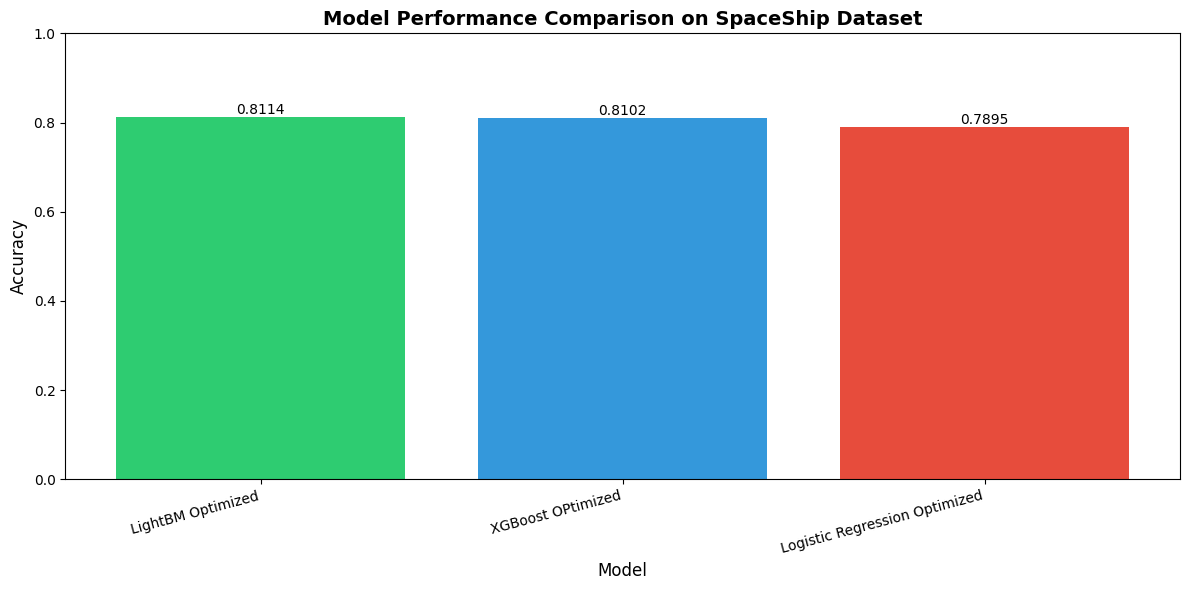

In [46]:
# Visualize model comparison
plt.figure(figsize=(12, 6))
bars = plt.bar(results['Model'], results['Accuracy'], color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Performance Comparison on SpaceShip Dataset', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.xticks(rotation=15, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#### **Confusion Matrixs**

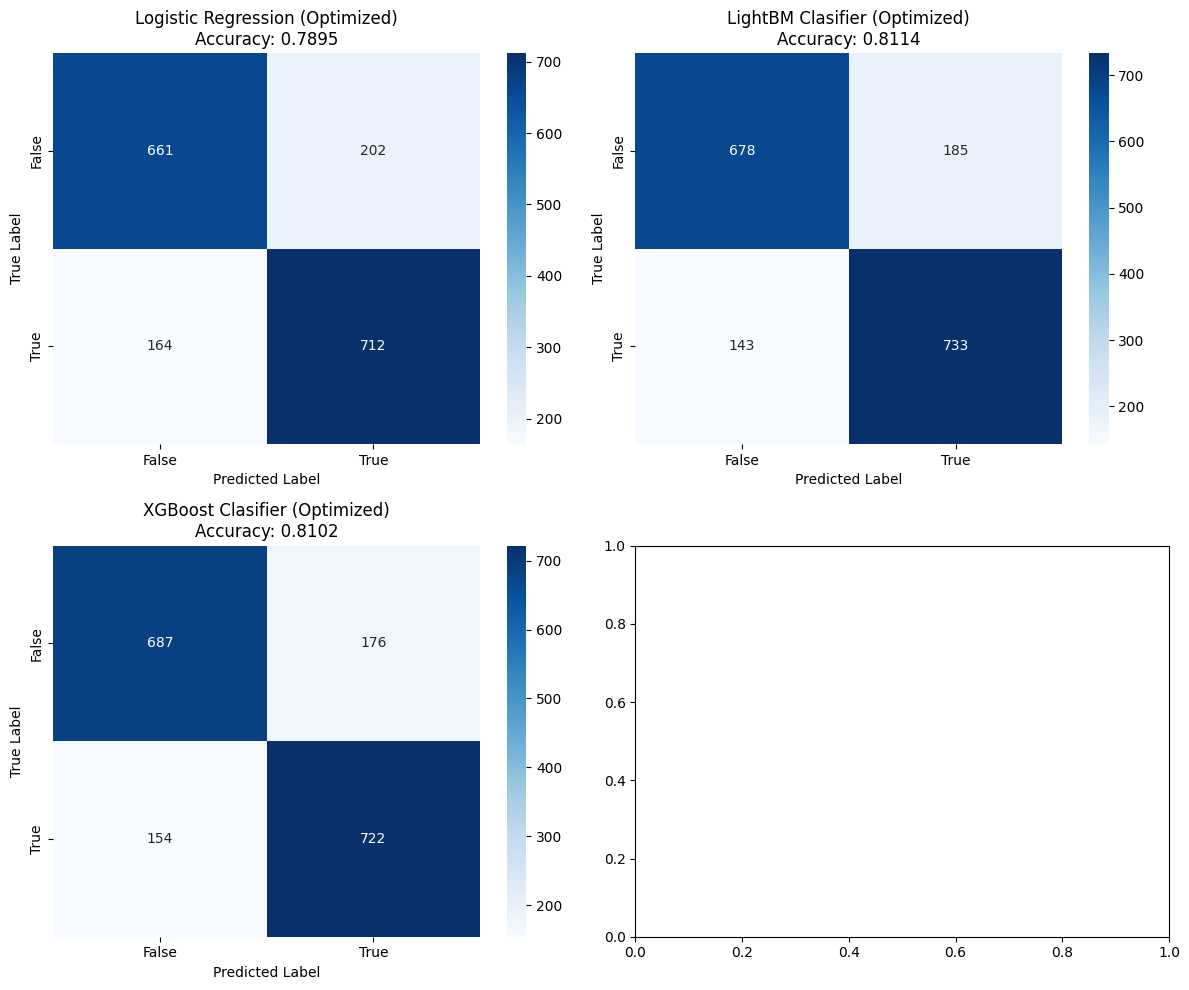

In [47]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

models = [
    ('Logistic Regression (Optimized)', y_pred_lr_optimized),
    ('LightBM Clasifier (Optimized)', y_pred_lgb_optimized),
    ('XGBoost Clasifier (Optimized)', y_pred_xgb_optimized)
]

for idx, (model_name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=["False", "True"],
                yticklabels=["False", "True"])
    axes[idx].set_title(f'{model_name}\nAccuracy: {accuracy_score(y_val, y_pred):.4f}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()